# GAN - g4 SpectralNorm discriminator

Esta versão parte da melhor configuração até agora, **g3_ema_generator**, e mantém:

- `START_FOLD = 0`, `END_FOLD = 20`;
- `LR_G = 2e-4`, `LR_D = 1e-4`;
- `REAL_LABEL = 1.0`, `FAKE_LABEL = 0.0`;
- EMA no gerador (`EMA_DECAY = 0.999`);
- mesma arquitetura do gerador.

A única alteração experimental desta fase é no **discriminador**:

- substituir as camadas `Conv2d` do discriminador por `spectral_norm(nn.Conv2d(...))`;
- remover `BatchNorm2d` do discriminador.

Hipótese:

> Como o g3 ainda apresenta saturação do discriminador, a Spectral Normalization deve regularizar o discriminador sem o tornar demasiado fraco como aconteceu no g2. Espera-se maior estabilidade adversarial e possível melhoria de FID/KID.


In [1]:
import os
import json
import base64
import io
import math
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import save_image, make_grid


import sys
sys.path.append(str(Path.cwd().parent))

from utils import DeepFakeDataset, dcganFormat  # <-- your utils module
from torch.nn.utils import spectral_norm

## Config

In [ ]:
# =========================================================
# Config - g4 SpectralNorm discriminator
# =========================================================
# Esta experiência parte do g3_ema_generator e altera apenas o discriminador:
# Conv2d com SpectralNorm e sem BatchNorm no D.

RUN_NAME = "g4_spectralnorm_discriminator"

REAL_DIR = "../../deepfake_data/wiki"
BASE_OUTPUT_DIR = "outputs"
OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, RUN_NAME)
SAMPLES_DIR = os.path.join(OUTPUT_DIR, "samples")
CHECKPOINTS_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")

IMAGE_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 100
NGF = 64
NDF = 64
NUM_CHANNELS = 3

# Parâmetros de treino - iguais ao g1/g3.
NUM_EPOCHS = 200
LR_G = 2e-4
LR_D = 1e-4
BETA1 = 0.5
SEED = 42
NUM_WORKERS = 0

# Sem label smoothing nesta fase. Queremos isolar o efeito da SpectralNorm.
REAL_LABEL = 1.0
FAKE_LABEL = 0.0

# Mantemos os mesmos folds do g1/g3 para comparação direta.
START_FOLD = 0
END_FOLD = 20
INTERVAL = True

# Logging / avaliação
SAMPLE_EVERY = 25          # guardar PNG com fixed_noise a cada N epochs
CHECKPOINT_EVERY = 10      # guardar checkpoint a cada N epochs
FID_EVERY = 50             # calcular FID/KID a cada N epochs
FID_NUM_IMAGES = 300       # ajustar para 2048/5000 se houver tempo/VRAM
SAVE_JSONL_EVERY = None    # usar 1 para guardar JSONL por epoch; None desliga JSONL
COMPUTE_KID = True

# EMA do gerador: mantém-se do g3.
USE_EMA = True
EMA_DECAY = 0.999

# Alteração principal do g4.
USE_SPECTRAL_NORM_D = True
REMOVE_BATCHNORM_D = True

# Epochs extra que queremos sempre guardar, mesmo que não calhem no intervalo
ALWAYS_SAVE_EPOCHS = {1, NUM_EPOCHS}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

# Criar pastas dos outputs desta run
for folder in [OUTPUT_DIR, SAMPLES_DIR, CHECKPOINTS_DIR, PLOTS_DIR, METRICS_DIR]:
    os.makedirs(folder, exist_ok=True)

# Reprodutibilidade
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Mantém alguma performance. Para reprodutibilidade máxima, pôr benchmark=False e deterministic=True.
torch.backends.cudnn.benchmark = True

print("Run:", RUN_NAME)
print("Device:", DEVICE)
print("Output dir:", OUTPUT_DIR)
print("SpectralNorm D:", USE_SPECTRAL_NORM_D)
print("BatchNorm removed from D:", REMOVE_BATCHNORM_D)


Run: g4_spectralnorm_discriminator
Device: cuda
Output dir: outputs\g4_spectralnorm_discriminator
SpectralNorm D: True
BatchNorm removed from D: True


## Utils

In [3]:
# =========================================================
# Utils de logging, samples e métricas
# =========================================================
from PIL import Image as PILImage


def denorm_to_01(x):
    """Converte tensores de [-1, 1] para [0, 1]."""
    return ((x + 1) / 2).clamp(0, 1)


def to_uint8_images(x):
    """Converte batch de imagens [-1,1] ou [0,1] para uint8 [0,255]."""
    if x.min() < 0:
        x = denorm_to_01(x)
    return (x * 255).clamp(0, 255).to(torch.uint8)


def should_run(epoch, every):
    if every is None:
        return False
    return epoch in ALWAYS_SAVE_EPOCHS or epoch % every == 0


def save_generated_samples_png(epoch, generator, noise, out_dir=SAMPLES_DIR, prefix="fixed_noise", nrow=8):
    """Guarda grelha PNG usando o fixed_noise."""
    was_training = generator.training
    generator.eval()
    with torch.no_grad():
        fake_images = denorm_to_01(generator(noise).detach().cpu())
        grid = make_grid(fake_images, nrow=nrow, padding=2, normalize=False)
        path = os.path.join(out_dir, f"{prefix}_epoch_{epoch:03d}.png")
        save_image(grid, path)
    if was_training:
        generator.train()
    return path


def save_samples_jsonl(epoch, generator, noise, path, nrow=8):
    """Append one lossless-PNG sample grid (base64) as a JSON line."""
    was_training = generator.training
    generator.eval()
    with torch.no_grad():
        fake = denorm_to_01(generator(noise).detach().cpu())
        grid = make_grid(fake, nrow=nrow, padding=2, normalize=False)
        arr = (grid.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype("uint8")
        buf = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG", optimize=True)
        b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    if was_training:
        generator.train()

    with open(path, "a") as f:
        f.write(json.dumps({"epoch": epoch, "format": "png", "grid_b64": b64}) + "\n")


def save_latent_interpolation(generator, latent_dim, device, out_path, steps=8, nrow=8):
    """Guarda uma interpolação linear entre dois vetores latentes."""
    was_training = generator.training
    generator.eval()
    z1 = torch.randn(1, latent_dim, 1, 1, device=device)
    z2 = torch.randn(1, latent_dim, 1, 1, device=device)
    alphas = torch.linspace(0, 1, steps=steps, device=device)
    z_interp = torch.cat([(1 - a) * z1 + a * z2 for a in alphas], dim=0)
    with torch.no_grad():
        imgs = denorm_to_01(generator(z_interp).detach().cpu())
        grid = make_grid(imgs, nrow=nrow, padding=2, normalize=False)
        save_image(grid, out_path)
    if was_training:
        generator.train()
    return out_path


def save_real_grid(dataloader, out_path, n=16, nrow=4):
    """Guarda uma grelha de imagens reais para referência visual."""
    batch = next(iter(dataloader))[:n].cpu()
    batch = denorm_to_01(batch)
    grid = make_grid(batch, nrow=nrow, padding=2, normalize=False)
    save_image(grid, out_path)
    return out_path


@torch.no_grad()
def update_ema(ema_model, model, decay=0.999):
    """Atualiza os pesos EMA do gerador: ema = decay*ema + (1-decay)*model."""
    for ema_param, param in zip(ema_model.parameters(), model.parameters()):
        ema_param.data.mul_(decay).add_(param.data, alpha=1.0 - decay)

    # Mantém buffers como running_mean/running_var de BatchNorm coerentes com o gerador atual.
    for ema_buffer, buffer in zip(ema_model.buffers(), model.buffers()):
        ema_buffer.data.copy_(buffer.data)


# ---- FID / KID opcionais ----
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.kid import KernelInceptionDistance
    TORCHMETRICS_AVAILABLE = True
    print("torchmetrics disponível: FID/KID serão calculados.")
except Exception as e:
    FrechetInceptionDistance = None
    KernelInceptionDistance = None
    TORCHMETRICS_AVAILABLE = False
    print("torchmetrics não disponível: FID/KID serão ignorados.")
    print("Para ativar: pip install torchmetrics[image] torch-fidelity")
    print("Erro:", repr(e))


@torch.no_grad()
def compute_fid_kid(
    generator,
    dataloader,
    num_images=1024,
    latent_dim=LATENT_DIM,
    device=DEVICE,
    compute_kid=False,
):
    """Calcula FID e, opcionalmente, KID com torchmetrics.

    Para evitar bloqueios/memória excessiva no VS Code/Jupyter, o KID fica
    desligado por defeito. Quando compute_kid=False, a função nem instancia
    KernelInceptionDistance, evitando o buffer grande de features.
    """
    import gc

    if not TORCHMETRICS_AVAILABLE:
        return {"fid": float("nan"), "kid_mean": float("nan"), "kid_std": float("nan")}

    was_training = generator.training
    generator.eval()

    n_target = min(int(num_images), len(dataloader.dataset))
    if n_target <= 0:
        if was_training:
            generator.train()
        return {"fid": float("nan"), "kid_mean": float("nan"), "kid_std": float("nan")}

    fid = FrechetInceptionDistance(feature=2048).to(device)
    kid = None
    if compute_kid:
        # subset_size tem de ser <= número de imagens usadas.
        kid = KernelInceptionDistance(subset_size=min(50, n_target)).to(device)

    # Imagens reais
    seen = 0
    for real in dataloader:
        if isinstance(real, (list, tuple)):
            real = real[0]
        real = real.to(device, non_blocking=True)

        take = min(real.size(0), n_target - seen)
        if take <= 0:
            break

        real_u8 = to_uint8_images(real[:take])
        fid.update(real_u8, real=True)
        if kid is not None:
            kid.update(real_u8, real=True)
        seen += take

        del real, real_u8

    # Imagens falsas
    seen = 0
    while seen < n_target:
        b = min(BATCH_SIZE, n_target - seen)
        noise = torch.randn(b, latent_dim, 1, 1, device=device)
        fake = generator(noise)
        fake_u8 = to_uint8_images(fake)

        fid.update(fake_u8, real=False)
        if kid is not None:
            kid.update(fake_u8, real=False)
        seen += b

        del noise, fake, fake_u8

    fid_value = float(fid.compute().detach().cpu())

    if kid is not None:
        kid_mean, kid_std = kid.compute()
        kid_mean = float(kid_mean.detach().cpu())
        kid_std = float(kid_std.detach().cpu())
    else:
        kid_mean = float("nan")
        kid_std = float("nan")

    del fid, kid
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if was_training:
        generator.train()

    return {
        "fid": fid_value,
        "kid_mean": kid_mean,
        "kid_std": kid_std,
    }

torchmetrics disponível: FID/KID serão calculados.


## Dataset & DataLoader

In [4]:
dataset = DeepFakeDataset(
    img_dir=REAL_DIR,
    label=1,                           # ignored; image_only=True
    transform=dcganFormat(IMAGE_SIZE),
    range_folds=[START_FOLD, END_FOLD],
    interval=INTERVAL,
    image_only=True,                   # GAN mode: return only image tensor
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)

print(f"Total de imagens reais: {len(dataset)}")
print(f"Folds usados: {dataset.fold_names}")

# Guardar grelha de imagens reais para comparação visual
real_grid_path = save_real_grid(dataloader, os.path.join(SAMPLES_DIR, "real_reference_grid.png"))
print("Grelha real guardada em:", real_grid_path)

Building ../../deepfake_data/wiki dataset with 20 folds:   0%|          | 0/20 [00:00<?, ?it/s]

Total de imagens reais: 5938
Folds usados: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19']
Grelha real guardada em: outputs\g4_spectralnorm_discriminator\samples\real_reference_grid.png


### Ver uma imagem do dataset

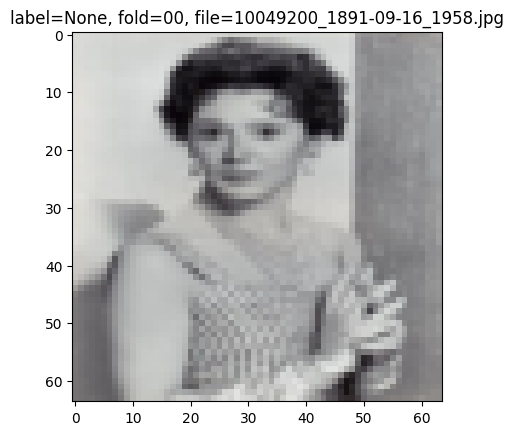

img_shape=torch.Size([3, 64, 64]), img_type=<class 'torch.Tensor'>, label=None, fold=00, file=10049200_1891-09-16_1958.jpg


tensor([[[ 0.7098,  0.7098,  0.7020,  ...,  0.2235,  0.3020,  0.3333],
         [ 0.7098,  0.7020,  0.6941,  ...,  0.2392,  0.2471,  0.2863],
         [ 0.6941,  0.7020,  0.6784,  ...,  0.2471,  0.2157,  0.2314],
         ...,
         [-0.0745, -0.0902, -0.1373,  ...,  0.0431,  0.0667,  0.0824],
         [-0.0824, -0.1059, -0.1451,  ...,  0.0745,  0.1137,  0.1137],
         [-0.0667, -0.0980, -0.1216,  ...,  0.1137,  0.1216,  0.1137]],

        [[ 0.7176,  0.7176,  0.7020,  ...,  0.2000,  0.2706,  0.3020],
         [ 0.7176,  0.7098,  0.6941,  ...,  0.2157,  0.2235,  0.2627],
         [ 0.6941,  0.7020,  0.6863,  ...,  0.2471,  0.2157,  0.2235],
         ...,
         [-0.0980, -0.1216, -0.1686,  ...,  0.0196,  0.0353,  0.0510],
         [-0.1059, -0.1294, -0.1608,  ...,  0.0431,  0.0824,  0.0824],
         [-0.0980, -0.1216, -0.1451,  ...,  0.0824,  0.0902,  0.0824]],

        [[ 0.6784,  0.6784,  0.6784,  ...,  0.1765,  0.2471,  0.2784],
         [ 0.6863,  0.6784,  0.6706,  ...,  0

In [5]:
dataset.show(0)

### Inicialização de pesos

In [6]:
# Esta função inicializa os pesos da rede.
# Para camadas com spectral_norm, o parâmetro original chama-se weight_orig.
def weights_init(m):
    classname = m.__class__.__name__

    if "Conv" in classname:
        if hasattr(m, "weight_orig"):
            nn.init.normal_(m.weight_orig.data, 0.0, 0.02)
        elif hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)

        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Isto mantém a inicialização clássica DCGAN, adaptada para SpectralNorm.

# Gerador

In [7]:
# O Gerador recebe um vetor aleatório z e tenta convertê-lo numa imagem falsa realista
class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=64, nc=3):
        super().__init__()

        self.init = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
        )

        self.main = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 8, ngf * 4, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 4, ngf * 2, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 2, ngf, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf, nc, 3, 1, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.init(z)
        return self.main(x)

# Discriminador

In [8]:
# Recebe uma imagem e tenta dizer se ela é real ou falsa.
# No g4, o discriminador usa SpectralNorm nas convoluções e remove BatchNorm.
# A ideia é regularizar D sem simplesmente reduzir demasiado o seu learning rate.
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64, use_spectral_norm=True):
        super().__init__()

        def conv(in_channels, out_channels, kernel_size, stride, padding):
            layer = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
            return spectral_norm(layer) if use_spectral_norm else layer

        self.main = nn.Sequential(
            # 64x64 -> 32x32
            conv(nc, ndf, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 -> 16x16
            conv(ndf, ndf * 2, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 -> 8x8
            conv(ndf * 2, ndf * 4, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8 -> 4x4
            conv(ndf * 4, ndf * 8, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 4x4 -> 1x1
            conv(ndf * 8, 1, 4, 1, 0),
        )

    def forward(self, x):
        return self.main(x).view(-1)


# Instanciar modelos

In [9]:
netG = Generator(LATENT_DIM, NGF, NUM_CHANNELS).to(DEVICE)
netD = Discriminator(NUM_CHANNELS, NDF, use_spectral_norm=USE_SPECTRAL_NORM_D).to(DEVICE)

netG.apply(weights_init)
netD.apply(weights_init)

# EMA começa como uma cópia exata do gerador inicial.
# Só é usado para avaliação/amostragem; não recebe gradientes.
netG_ema = copy.deepcopy(netG).to(DEVICE).eval()
for p in netG_ema.parameters():
    p.requires_grad_(False)

print(netG)
print(netD)
print("EMA generator active:", USE_EMA)
print("SpectralNorm discriminator active:", USE_SPECTRAL_NORM_D)


Generator(
  (init): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (main): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Upsample(scale_factor=2.0, mode='nearest')
    (5): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Upsample(scale_factor=2.0, mode='nearest')
    (9): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [10]:
# Loss binária com logits
# O discriminador devolve logits crus, sem sigmoid, esta loss combina sigmoid e binary cross entropy de forma mais estavel numericamente
criterion = nn.BCEWithLogitsLoss()

# Otimizadores Adam para o discriminador e o gerador
optimizerD = optim.Adam(netD.parameters(), lr=LR_D, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR_G, betas=(BETA1, 0.999))

# Ruido fixo para as amostras. Este ruido serve para gerar sempre as mesmas 64 imagens ao longo do treino.
# Deste modo podemos ver a evolução do gerador de forma consistente (na epoch 1, 10, 50, etc)
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=DEVICE)

## Função para guardar amostras

In [11]:
# Wrapper compatível com versões anteriores do notebook
def save_generated_samples(epoch, generator, noise):
    return save_generated_samples_png(epoch, generator, noise)

## Treino

In [12]:
print("CUDA available:", torch.cuda.is_available())
print("netG on:", next(netG.parameters()).device)
print("netD on:", next(netD.parameters()).device)

CUDA available: True
netG on: cuda:0
netD on: cuda:0


In [ ]:
from tqdm.auto import tqdm

# =========================================================
# Treino - g4 SpectralNorm discriminator
# =========================================================
# Parte do g3_ema_generator. Mantemos EMA no gerador; a novidade é o discriminador
# com SpectralNorm e sem BatchNorm.

history = []
fid_history = []
g_losses, d_losses = [], []

history_path = os.path.join(METRICS_DIR, "training_history.csv")
fid_path = os.path.join(METRICS_DIR, "fid_kid_history.csv")
config_path = os.path.join(OUTPUT_DIR, "run_config.json")

run_config = {
    "run_name": RUN_NAME,
    "real_dir": REAL_DIR,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "latent_dim": LATENT_DIM,
    "ngf": NGF,
    "ndf": NDF,
    "num_epochs": NUM_EPOCHS,
    "lr_g": LR_G,
    "lr_d": LR_D,
    "beta1": BETA1,
    "real_label": REAL_LABEL,
    "fake_label": FAKE_LABEL,
    "use_ema": USE_EMA,
    "ema_decay": EMA_DECAY,
    "use_spectral_norm_d": USE_SPECTRAL_NORM_D,
    "remove_batchnorm_d": REMOVE_BATCHNORM_D,
    "seed": SEED,
    "start_fold": START_FOLD,
    "end_fold": END_FOLD,
    "interval": INTERVAL,
    "sample_every": SAMPLE_EVERY,
    "checkpoint_every": CHECKPOINT_EVERY,
    "fid_every": FID_EVERY,
    "fid_num_images": FID_NUM_IMAGES,
    "compute_kid": COMPUTE_KID,
    "num_workers": NUM_WORKERS,
    "num_real_images": len(dataset),
    "folds_used": list(dataset.fold_names),
}
with open(config_path, "w") as f:
    json.dump(run_config, f, indent=2)

# JSONL opcional para evolução detalhada por epoch
if SAVE_JSONL_EVERY is not None:
    samples_jsonl_path = os.path.join(OUTPUT_DIR, "samples_evolution.jsonl")
    open(samples_jsonl_path, "w").close()
else:
    samples_jsonl_path = None

def eval_generator():
    """Gerador usado para avaliação: EMA no g3, G normal se USE_EMA=False."""
    return netG_ema if USE_EMA else netG

# Guardar samples iniciais antes do treino
save_generated_samples_png(0, eval_generator(), fixed_noise, prefix="fixed_noise_initial")

print("A começar treino g4...")
epoch_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Training", unit="epoch")

for epoch in epoch_bar:
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    epoch_dx = 0.0
    epoch_dgz_fake = 0.0
    epoch_dgz_gen = 0.0

    batch_bar = tqdm(dataloader, desc=f"Epoch {epoch}", leave=False, unit="batch")
    for real_images in batch_bar:
        real_images = real_images.to(DEVICE)
        b_size = real_images.size(0)

        # --- Discriminator ---
        netD.zero_grad(set_to_none=True)
        output_real = netD(real_images)
        real_targets = torch.full((b_size,), REAL_LABEL, device=DEVICE)
        lossD_real = criterion(output_real, real_targets)

        noise = torch.randn(b_size, LATENT_DIM, 1, 1, device=DEVICE)
        fake_images = netG(noise)
        output_fake = netD(fake_images.detach())
        fake_targets = torch.full((b_size,), FAKE_LABEL, device=DEVICE)
        lossD_fake = criterion(output_fake, fake_targets)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # --- Generator ---
        netG.zero_grad(set_to_none=True)
        output_gen = netD(fake_images)
        gen_targets = torch.full((b_size,), REAL_LABEL, device=DEVICE)
        lossG = criterion(output_gen, gen_targets)
        lossG.backward()
        optimizerG.step()

        # Atualizar EMA do gerador depois de cada update de G.
        if USE_EMA:
            update_ema(netG_ema, netG, EMA_DECAY)

        # Métricas por batch
        with torch.no_grad():
            dx = torch.sigmoid(output_real).mean().item()
            dgz_fake = torch.sigmoid(output_fake).mean().item()
            dgz_gen = torch.sigmoid(output_gen).mean().item()

        epoch_d_loss += lossD.item()
        epoch_g_loss += lossG.item()
        epoch_dx += dx
        epoch_dgz_fake += dgz_fake
        epoch_dgz_gen += dgz_gen

        batch_bar.set_postfix(d=f"{lossD.item():.3f}", g=f"{lossG.item():.3f}", dx=f"{dx:.2f}")

    n = len(dataloader)
    avg_d = epoch_d_loss / n
    avg_g = epoch_g_loss / n
    avg_dx = epoch_dx / n
    avg_dgz_fake = epoch_dgz_fake / n
    avg_dgz_gen = epoch_dgz_gen / n

    d_losses.append(avg_d)
    g_losses.append(avg_g)

    row = {
        "run_name": RUN_NAME,
        "epoch": epoch,
        "loss_d": avg_d,
        "loss_g": avg_g,
        "D_x": avg_dx,
        "D_G_z_fake": avg_dgz_fake,
        "D_G_z_gen": avg_dgz_gen,
    }
    history.append(row)
    pd.DataFrame(history).to_csv(history_path, index=False)

    epoch_bar.set_postfix(loss_d=f"{avg_d:.3f}", loss_g=f"{avg_g:.3f}", d_x=f"{avg_dx:.2f}", dgz=f"{avg_dgz_gen:.2f}")

    # Samples PNG selecionadas - no g4 continuamos a usar EMA.
    if should_run(epoch, SAMPLE_EVERY):
        save_generated_samples_png(epoch, eval_generator(), fixed_noise, prefix="fixed_noise")

    # JSONL opcional - no g4 continuamos a usar EMA.
    if SAVE_JSONL_EVERY is not None and should_run(epoch, SAVE_JSONL_EVERY):
        save_samples_jsonl(epoch, eval_generator(), fixed_noise, samples_jsonl_path)

    # FID/KID selecionado - no g4 avaliamos EMA.
    if FID_EVERY is not None and (epoch % FID_EVERY == 0 or epoch == NUM_EPOCHS):
        metrics = compute_fid_kid(eval_generator(), dataloader, num_images=FID_NUM_IMAGES, compute_kid=COMPUTE_KID)
        metrics.update({"run_name": RUN_NAME, "epoch": epoch, "evaluated_model": "ema" if USE_EMA else "raw", "discriminator": "spectral_norm_no_bn" if USE_SPECTRAL_NORM_D else "baseline"})
        fid_history.append(metrics)
        pd.DataFrame(fid_history).to_csv(fid_path, index=False)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        if COMPUTE_KID:
            print(f"Epoch {epoch:03d} | FID: {metrics['fid']:.3f} | KID: {metrics['kid_mean']:.5f} ± {metrics['kid_std']:.5f} | model: {'EMA' if USE_EMA else 'raw'}")
        else:
            print(f"Epoch {epoch:03d} | FID: {metrics['fid']:.3f} | KID: desligado | model: {'EMA' if USE_EMA else 'raw'}")

    # Checkpoints selecionados
    if should_run(epoch, CHECKPOINT_EVERY):
        checkpoint = {
            "epoch": epoch,
            "netG_state_dict": netG.state_dict(),
            "netD_state_dict": netD.state_dict(),
            "optimizerG_state_dict": optimizerG.state_dict(),
            "optimizerD_state_dict": optimizerD.state_dict(),
            "g_losses": g_losses,
            "d_losses": d_losses,
            "history": history,
            "fid_history": fid_history,
            "config": run_config,
        }
        if USE_EMA:
            checkpoint["netG_ema_state_dict"] = netG_ema.state_dict()
        torch.save(checkpoint, os.path.join(CHECKPOINTS_DIR, f"dcgan_{RUN_NAME}_epoch_{epoch:03d}.pt"))

# Artefactos finais - no g4 continuamos a usar EMA.
interpolation_path = save_latent_interpolation(
    eval_generator(),
    LATENT_DIM,
    DEVICE,
    os.path.join(SAMPLES_DIR, "latent_interpolation_final.png"),
    steps=8,
    nrow=8,
)
print("Treino terminado.")
print("Histórico:", history_path)
print("FID/KID:", fid_path)
print("Interpolação latente:", interpolation_path)


A começar treino g4...


Training:   0%|          | 0/200 [00:00<?, ?epoch/s]

Epoch 1:   0%|          | 0/92 [00:00<?, ?batch/s]

Epoch 2:   0%|          | 0/92 [00:00<?, ?batch/s]

Epoch 3:   0%|          | 0/92 [00:00<?, ?batch/s]

...

Epoch 198:   0%|          | 0/92 [00:00<?, ?batch/s]

Epoch 199:   0%|          | 0/92 [00:00<?, ?batch/s]

Epoch 200:   0%|          | 0/92 [00:00<?, ?batch/s]

c:\Users\User\MIA\DRL\Project\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Epoch 200 | FID: 228.509 | KID: 0.11244 ± 0.01011 | model: EMA
Treino terminado.
Histórico: outputs\g4_spectralnorm_discriminator\metrics\training_history.csv
FID/KID: outputs\g4_spectralnorm_discriminator\metrics\fid_kid_history.csv
Interpolação latente: outputs\g4_spectralnorm_discriminator\samples\latent_interpolation_final.png


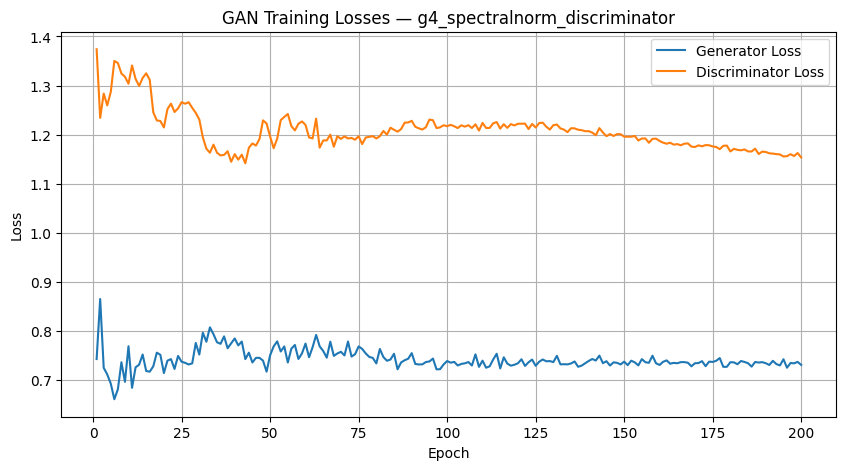

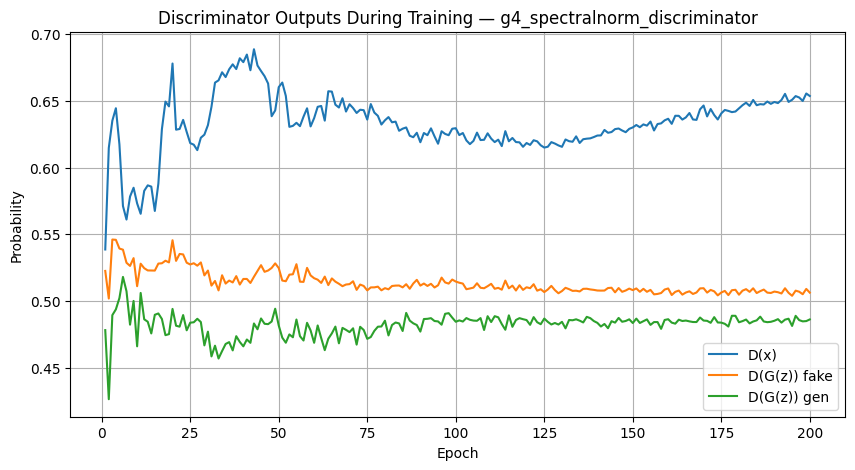

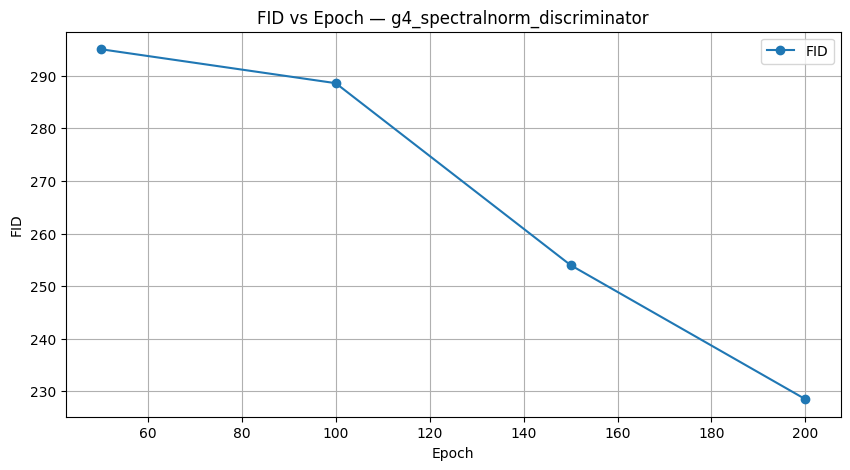

Plots guardados em: outputs\g4_spectralnorm_discriminator\plots


In [ ]:
import matplotlib.pyplot as plt

history_path = os.path.join(METRICS_DIR, "training_history.csv")
history_df = pd.read_csv(history_path)

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["loss_g"], label="Generator Loss")
plt.plot(history_df["epoch"], history_df["loss_d"], label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"GAN Training Losses - {RUN_NAME}")
plt.legend()
plt.grid(True)
loss_plot_path = os.path.join(PLOTS_DIR, "loss_curves.png")
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["D_x"], label="D(x)")
plt.plot(history_df["epoch"], history_df["D_G_z_fake"], label="D(G(z)) fake")
plt.plot(history_df["epoch"], history_df["D_G_z_gen"], label="D(G(z)) gen")
plt.xlabel("Epoch")
plt.ylabel("Probability")
plt.title(f"Discriminator Outputs During Training - {RUN_NAME}")
plt.legend()
plt.grid(True)
d_plot_path = os.path.join(PLOTS_DIR, "discriminator_outputs.png")
plt.savefig(d_plot_path, dpi=150, bbox_inches="tight")
plt.show()

fid_path = os.path.join(METRICS_DIR, "fid_kid_history.csv")
if os.path.exists(fid_path):
    fid_df = pd.read_csv(fid_path)
    if "fid" in fid_df and fid_df["fid"].notna().any():
        plt.figure(figsize=(10, 5))
        plt.plot(fid_df["epoch"], fid_df["fid"], marker="o", label="FID")
        plt.xlabel("Epoch")
        plt.ylabel("FID")
        plt.title(f"FID vs Epoch - {RUN_NAME}")
        plt.legend()
        plt.grid(True)
        fid_plot_path = os.path.join(PLOTS_DIR, "fid_curve.png")
        plt.savefig(fid_plot_path, dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("FID existe, mas está vazio/NaN. Verificar torchmetrics/torch-fidelity.")
else:
    print("Ainda não existe ficheiro FID/KID. Corre o treino primeiro.")

print("Plots guardados em:", PLOTS_DIR)

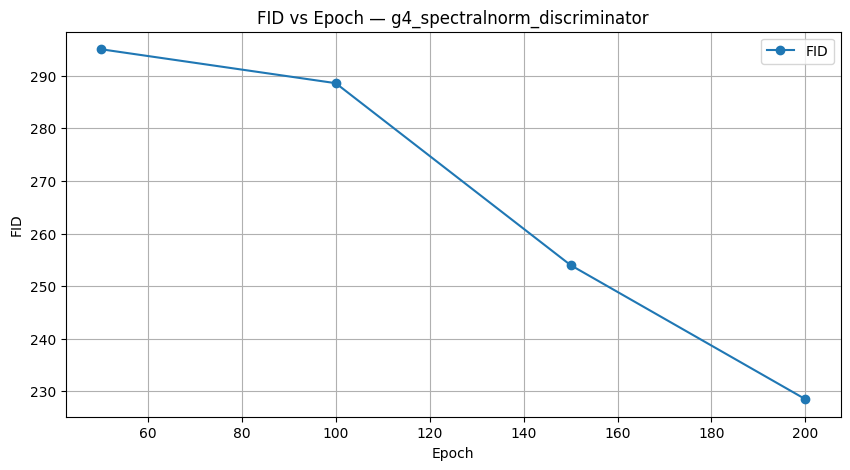

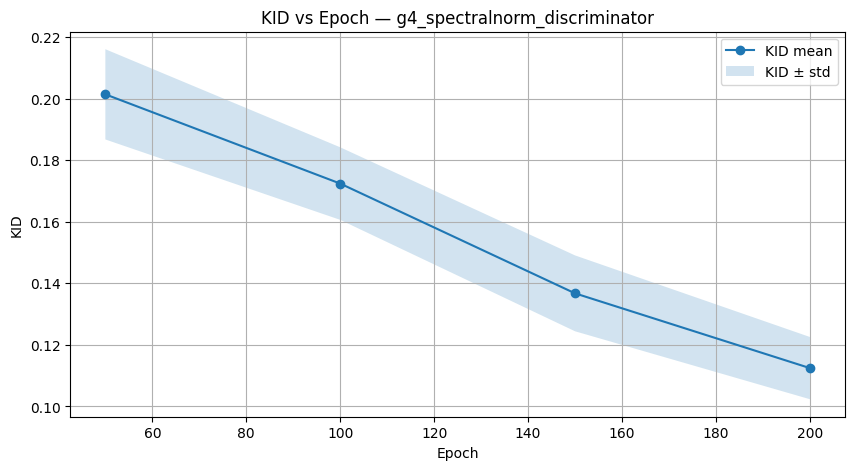

Plots guardados em: outputs\g4_spectralnorm_discriminator\plots


In [ ]:
fid_path = os.path.join(METRICS_DIR, "fid_kid_history.csv")

if os.path.exists(fid_path):
    fid_df = pd.read_csv(fid_path)

    # --- FID plot ---
    if "fid" in fid_df.columns and fid_df["fid"].notna().any():
        plt.figure(figsize=(10, 5))
        plt.plot(fid_df["epoch"], fid_df["fid"], marker="o", label="FID")
        plt.xlabel("Epoch")
        plt.ylabel("FID")
        plt.title(f"FID vs Epoch - {RUN_NAME}")
        plt.legend()
        plt.grid(True)

        fid_plot_path = os.path.join(PLOTS_DIR, "fid_curve.png")
        plt.savefig(fid_plot_path, dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("FID existe, mas está vazio/NaN. Verificar torchmetrics/torch-fidelity.")

    # --- KID plot, only if available ---
    if "kid_mean" in fid_df.columns and fid_df["kid_mean"].notna().any():
        plt.figure(figsize=(10, 5))
        plt.plot(fid_df["epoch"], fid_df["kid_mean"], marker="o", label="KID mean")

        if "kid_std" in fid_df.columns and fid_df["kid_std"].notna().any():
            lower = fid_df["kid_mean"] - fid_df["kid_std"]
            upper = fid_df["kid_mean"] + fid_df["kid_std"]
            plt.fill_between(fid_df["epoch"], lower, upper, alpha=0.2, label="KID ± std")

        plt.xlabel("Epoch")
        plt.ylabel("KID")
        plt.title(f"KID vs Epoch - {RUN_NAME}")
        plt.legend()
        plt.grid(True)

        kid_plot_path = os.path.join(PLOTS_DIR, "kid_curve.png")
        plt.savefig(kid_plot_path, dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("KID desligado ou sem valores válidos; a avaliação desta run usa FID como métrica principal.")

else:
    print("Ainda não existe ficheiro FID/KID. Corre o treino primeiro.")

print("Plots guardados em:", PLOTS_DIR)

Como o D devolve logits, aplicas sigmoid para obter algo parecido com probabilidade.

- `D(x):` Probabilidade média atribuída às imagens reais. (idealmente alta)

- `D(G(z)) fake:` Probabilidade média atribuída às falsas quando treinas o D. (idealmente baixa)

- `D(G(z)) gen:` Probabilidade média atribuída às falsas quando observadas no passo do G. (se começar a subir, pode indicar que o G está a enganar melhor o D)

# Gerar imagens a partir do último modelo em memória

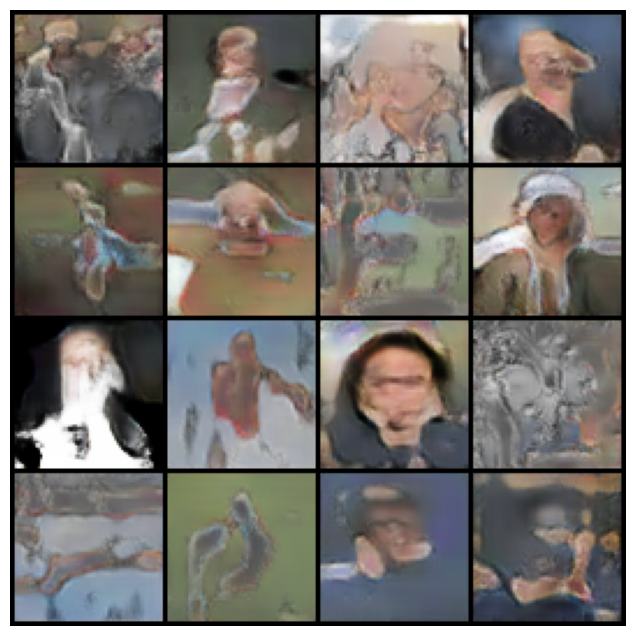

Samples guardadas em: outputs\g4_spectralnorm_discriminator\samples\manual_random_samples.png


In [16]:
manual_gen = netG_ema if USE_EMA else netG
manual_gen.eval()
with torch.no_grad():
    noise = torch.randn(16, LATENT_DIM, 1, 1, device=DEVICE)
    fake_images = denorm_to_01(manual_gen(noise).cpu())

grid = make_grid(fake_images, nrow=4, padding=2)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

manual_sample_path = os.path.join(SAMPLES_DIR, "manual_random_samples.png")
save_image(grid, manual_sample_path)
print("Samples guardadas em:", manual_sample_path)


# Confirmar que os dados estão bem:

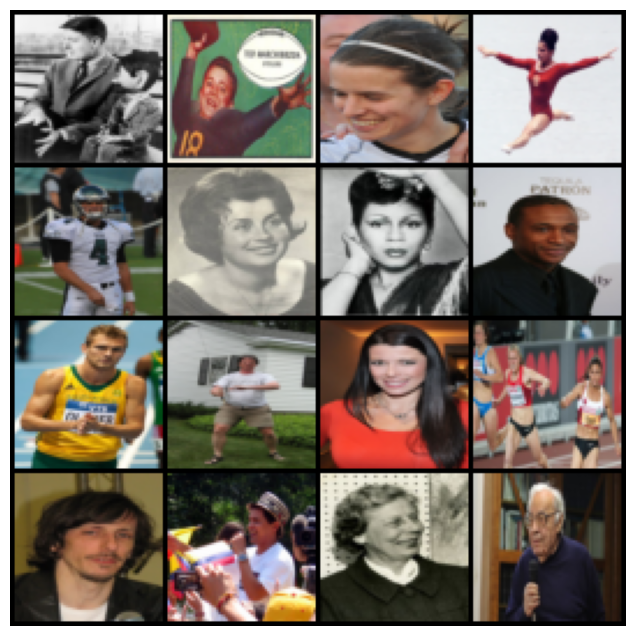

In [17]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

real_batch = next(iter(dataloader))
real_batch = denorm_to_01(real_batch[:16].cpu())

grid = make_grid(real_batch, nrow=4, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

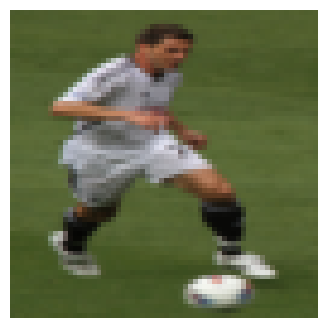

In [18]:
real_batch = next(iter(dataloader))
img = denorm_to_01(real_batch[0].cpu())

import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [19]:
# Resumo rápido da run para copiar para o JOURNAL.md
summary = {
    "Iteration": "g4_spectralnorm_discriminator",
    "Change": "g3_ema_generator + SpectralNorm on discriminator convolutions; BatchNorm removed from D",
    "FID @ end": None,
    "Notes": "Testa se regularizar D com SpectralNorm reduz saturação sem enfraquecer demasiado o discriminador como no g2.",
}

fid_path = os.path.join(METRICS_DIR, "fid_kid_history.csv")
if os.path.exists(fid_path):
    fid_df = pd.read_csv(fid_path)
    if len(fid_df) > 0 and fid_df["fid"].notna().any():
        summary["FID @ end"] = float(fid_df.dropna(subset=["fid"]).iloc[-1]["fid"])
        best_row = fid_df.dropna(subset=["fid"]).sort_values("fid").iloc[0]
        summary["Best FID"] = float(best_row["fid"])
        summary["Best FID epoch"] = int(best_row["epoch"])
        if "kid_mean" in fid_df.columns and fid_df["kid_mean"].notna().any():
            summary["KID @ end"] = float(fid_df.dropna(subset=["kid_mean"]).iloc[-1]["kid_mean"])

print(json.dumps(summary, indent=2, ensure_ascii=False))


{
  "Iteration": "g4_spectralnorm_discriminator",
  "Change": "g3_ema_generator + SpectralNorm on discriminator convolutions; BatchNorm removed from D",
  "FID @ end": 228.5091857910156,
  "Notes": "Testa se regularizar D com SpectralNorm reduz saturação sem enfraquecer demasiado o discriminador como no g2.",
  "Best FID": 228.5091857910156,
  "Best FID epoch": 200,
  "KID @ end": 0.1124432832002639
}


# Conclusão

**Resultados do g4:**

- A SpectralNorm fez exatamente aquilo que queríamos no discriminador, mas prejudicou o FID em relação ao g3.

| Epoch |        FID |   KID mean | KID std |
| ----: | ---------: | ---------: | ------: |
|    50 |     295.04 |     0.2014 |  0.0147 |
|   100 |     288.58 |     0.1724 |  0.0118 |
|   150 |     254.00 |     0.1367 |  0.0123 |
|   200 | **228.51** | **0.1124** |  0.0101 |

- Comparação com versões anteriores:

| Fase | Alteração                    |  FID final |  KID final | Decisão                   |
| ---- | ---------------------------- | ---------: | ---------: | ------------------------- |
| g0   | baseline                     |    ~307.24 |     ~0.201 | baseline                  |
| g1   | mais dados                   | **208.99** | **0.0887** | forte melhoria            |
| g2   | LR_D menor + label smoothing |     244.18 |     0.1317 | negativo                  |
| g3   | g1 + EMA                     | **205.77** | **0.0889** | melhor até agora          |
| g4   | g3 + SpectralNorm D sem BN   |     228.51 |     0.1124 | equilibrado, mas pior FID |



**Interpretação:**

- O discriminador deixou de saturar.
- No g3, tinhamos algo como:

   D(x) ≈ 0.99
   D(G(z)) ≈ 0.005

- No g4, no fim tens aproximadamente:

   D(x) ≈ 0.65
   D(G(z)) fake ≈ 0.51
   D(G(z)) gen ≈ 0.49

- Isto mostra que a SpectralNorm + remoção de BatchNorm tornou o discriminador muito menos dominante. O jogo adversarial ficou muito mais equilibrado.

**Problema:**

- O equilíbrio parece ter sido demasiado forte. O discriminador ficou pouco confiante e provavelmente deixou de fornecer um sinal suficientemente exigente ao gerador. Por isso o FID piorou de 205.77 no g3 para 228.51 no g4.

- Visualmente, as imagens também parecem mais “lavadas”/suaves e menos definidas do que no g3. Há alguma estrutura humana, mas mais manchas e menos contraste facial.

| Fase | Base | Mudança | Métrica a comparar |
|---|---|---|---|
| g3 | g1 + EMA | EMA no G | FID/KID, samples, D outputs |
| g4 | g3 | SpectralNorm D sem BatchNorm D | FID/KID, samples, D outputs |

**Decisão após correr:**

- Manter g4 se melhorar FID/KID ou se produzir samples claramente melhores sem colapso.
- Se FID piorar, documentar como resultado negativo/parcial e manter g3 como melhor versão.


---

In g4, we regularized the discriminator using spectral normalization and removed BatchNorm from D. This successfully prevented discriminator saturation: unlike g3, where D(x) approached 1 and D(G(z)) approached 0, g4 kept discriminator outputs closer to the decision boundary. However, FID worsened from 205.77 to 228.51 and the generated images became less sharp. This suggests that the discriminator became too constrained to provide a strong learning signal. Therefore, g4 was kept as an informative negative result, while g3 remained the best-performing generator.

| g4 | spectralnorm_discriminator | Add spectral normalization to D and remove BatchNorm, keeping g3 EMA setup | FID worsened from g3 205.77 to 228.51; KID worsened from ~0.0889 to 0.1124 | Partial/negative result. SpectralNorm successfully prevented D saturation, with D(x)≈0.65 and D(G(z))≈0.49, but image quality decreased. Do not keep as final; g3 remains best. |